# Notebook 03 – Exploratory Data Analysis (EDA)

This notebook explores customer behavior and identifies patterns associated with customer churn.

The analysis focuses on understanding the relationship between customer characteristics, subscribed services, contract information, billing behavior, and churn.

### Objectives

- Understand the distribution of customer churn.
- Analyze customer demographics and account characteristics.
- Examine the relationship between services and churn.
- Investigate contract and payment behavior.
- Analyze tenure and billing patterns.
- Identify key factors associated with customer churn.
- Translate analytical findings into actionable business insights.

## Import Required Libraries

The following libraries are used for data manipulation, statistical analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Clean Dataset

The cleaned dataset generated in Notebook 02 is loaded for exploratory analysis. The raw dataset is not modified during this analysis.

In [3]:
df = pd.read_csv("../data/processed/telco_customer_churn_clean.csv")

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## EDA Variable Overview

The dataset contains demographic, service, contract, and billing variables. The following layout provides a structured reference before beginning the exploratory analysis.

In [8]:
eda_layout = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values,
    "Role": [
        "Identifier" if col == "customerID"
        else "Target" if col == "Churn"
        else "Predictor"
        for col in df.columns
    ]
})

eda_layout

,Variable,Data Type,Unique Values,Role
0,customerID,str,7043,Identifier
1,gender,str,2,Predictor
2,SeniorCitizen,int64,2,Predictor
3,Partner,str,2,Predictor
4,Dependents,str,2,Predictor
5,tenure,int64,73,Predictor
6,PhoneService,str,2,Predictor
7,MultipleLines,str,3,Predictor
8,InternetService,str,3,Predictor
9,OnlineSecurity,str,3,Predictor


## Churn Distribution

Understanding the overall churn rate provides a baseline for evaluating customer retention and establishes the distribution of the target variable before investigating individual churn drivers.

In [9]:
churn_counts = df["Churn"].value_counts()

churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_percentage

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

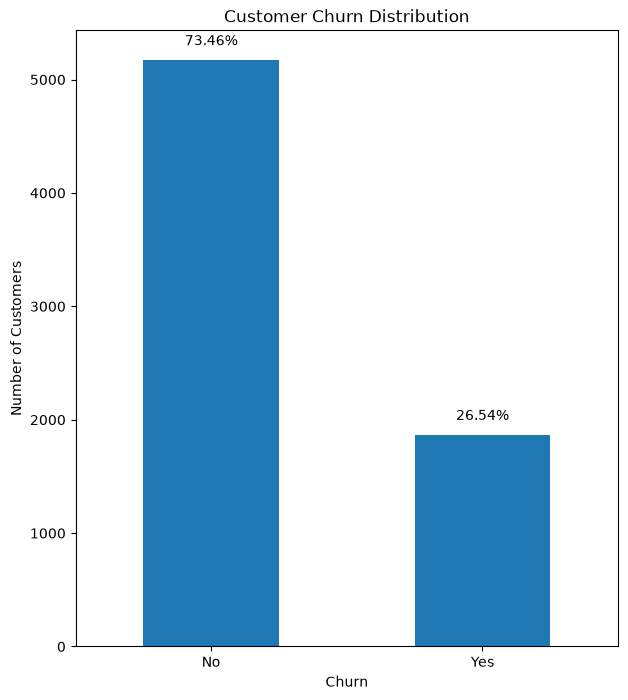

In [11]:
plt.figure(figsize=(7, 8))

ax = churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add percentages above bars
for i, value in enumerate(churn_counts):
    percentage = churn_percentage.iloc[i]
    ax.text(
        i,
        value + 100,
        f"{percentage:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

## 📌 Business Observation

**Observation**

The dataset contains 7,043 customers, of which 1,869 (**26.54%**) have churned and 5,174 (**73.46%**) have remained with the company.

**Business Impact**

Approximately one in four customers has churned. This indicates a meaningful customer retention challenge and provides a baseline against which churn patterns across customer segments, services, contracts, and billing characteristics can be evaluated.

**Next Step**

Examine customer demographics to determine whether churn rates differ across key customer groups.

## Customer Demographics

### Gender

This analysis examines whether customer churn differs by gender. Churn rates are calculated within each gender group to account for differences in group size.

In [12]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

gender_churn

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


In [13]:
gender_summary = (
    df.groupby("gender")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

gender_summary

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


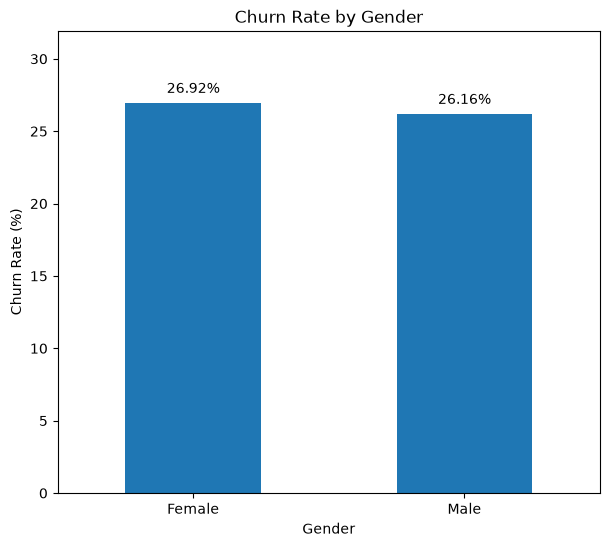

In [14]:
gender_churn_rate = gender_summary["Yes"]

plt.figure(figsize=(7, 6))

ax = gender_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(gender_churn_rate):
    ax.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(gender_churn_rate) + 5)

plt.show()

## 📌 Business Observation — Gender

**Observation**

Churn rates are very similar across genders. Female customers have a churn rate of **26.92%**, compared with **26.16%** among male customers.

**Business Impact**

Gender does not appear to be a meaningful differentiator of customer churn in this dataset. Retention strategies should therefore not prioritize gender-based segmentation.

**Key Insight**

The difference between female and male churn rates is only **0.76 percentage points**, indicating minimal variation.

**Next Step**

Analyze whether churn varies across other customer characteristics, beginning with **Senior Citizen status**.

## Senior Citizen Analysis

This analysis examines whether customer churn differs between senior and non-senior customers.

In [15]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [16]:
senior_labels = {
    0: "Non-Senior",
    1: "Senior"
}

df["SeniorCitizenLabel"] = df["SeniorCitizen"].map(senior_labels)

In [17]:
pd.crosstab(
    df["SeniorCitizenLabel"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
SeniorCitizenLabel,,
Non-Senior,76.39,23.61
Senior,58.32,41.68


## 📌 Business Observation — Senior Citizen

**Observation**

Senior customers have a churn rate of **41.68%**, compared with **23.61%** among non-senior customers.

**Business Impact**

Senior customers show a substantially higher likelihood of churn. The churn-rate difference of **18.07 percentage points** suggests that senior-customer status may be an important factor associated with customer retention.

**Key Insight**

Unlike gender, which showed minimal variation in churn, Senior Citizen status demonstrates a pronounced difference in churn behavior.

**Next Step**

Investigate whether other customer characteristics, such as **Partner and Dependents**, are associated with differences in churn rates.

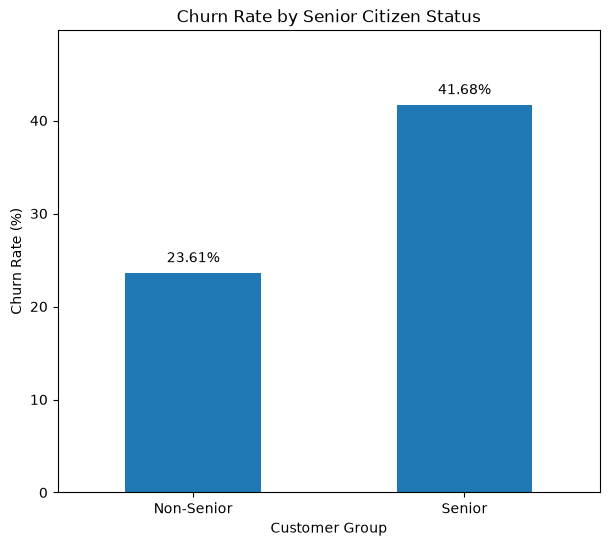

In [18]:
senior_churn_rate = (
    pd.crosstab(
        df["SeniorCitizenLabel"],
        df["Churn"],
        normalize="index"
    )["Yes"]
    .mul(100)
    .round(2)
)

plt.figure(figsize=(7, 6))

ax = senior_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(senior_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(senior_churn_rate) + 8)

plt.show()

## Partner Analysis

This analysis examines whether customer churn differs between customers who have a partner and those who do not.

In [19]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

partner_churn

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


## 📌 Business Observation — Partner

**Observation**

Customers without a partner have a churn rate of **32.96%**, compared with **19.66%** among customers who have a partner.

**Business Impact**

Customers without a partner show a substantially higher churn rate. The difference of **13.30 percentage points** suggests that Partner status is associated with customer retention behavior.

**Key Insight**

Partner status shows a stronger relationship with churn than gender, although the difference is smaller than the gap observed for Senior Citizen status.

**Next Step**

Analyze **Dependents** to determine whether household structure provides additional insight into customer churn.

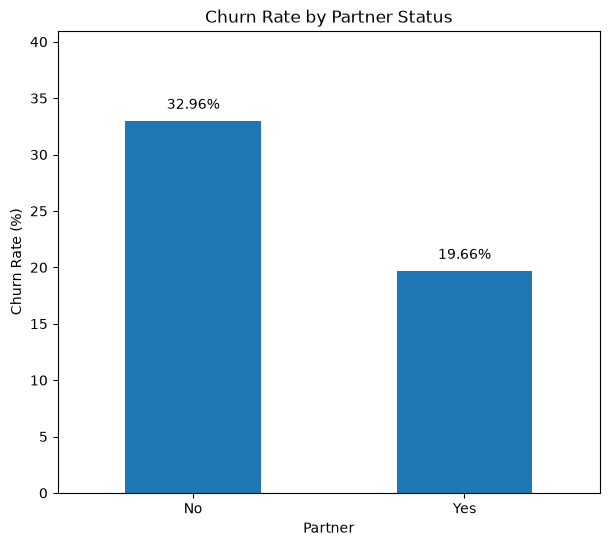

In [20]:
partner_churn_rate = partner_churn["Yes"]

plt.figure(figsize=(7, 6))

ax = partner_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(partner_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(partner_churn_rate) + 8)

plt.show()

## Dependents Analysis

This analysis examines whether customer churn differs between customers with and without dependents.

In [21]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

dependents_churn

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


## 📌 Business Observation — Dependents

**Observation**

Customers without dependents have a churn rate of **31.28%**, compared with **15.45%** among customers with dependents.

**Business Impact**

Customers without dependents show a substantially higher churn rate. The difference of **15.83 percentage points** suggests that Dependents status is strongly associated with customer retention behavior.

**Key Insight**

Household characteristics appear to be more informative for churn analysis than gender. Customers without dependents may represent an important segment for further retention analysis.

**Next Step**

Move from customer demographics to **account behavior**, beginning with **Tenure**, to examine whether the length of the customer relationship is associated with churn.

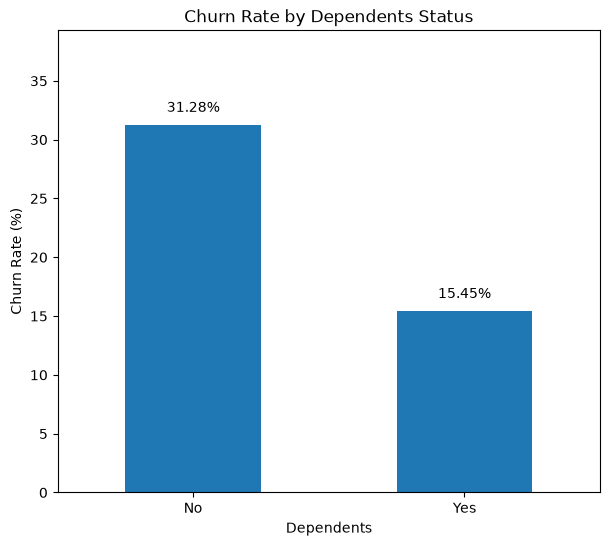

In [22]:
dependents_churn_rate = dependents_churn["Yes"]

plt.figure(figsize=(7, 6))

ax = dependents_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(dependents_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(dependents_churn_rate) + 8)

plt.show()

## Account Behavior

### Tenure Analysis

Tenure represents the number of months a customer has remained with the company.

This analysis examines the distribution of customer tenure and investigates whether customers with shorter or longer relationships show different churn behavior.

In [23]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [24]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


<Figure size 700x600 with 0 Axes>

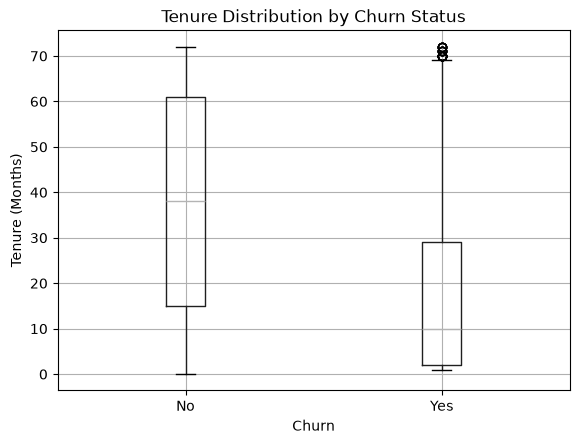

In [25]:
plt.figure(figsize=(7, 6))

df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## Tenure Band Analysis

Customers are grouped into tenure bands to examine how churn rates change as the customer relationship matures.

In [26]:
tenure_bins = [0, 12, 24, 48, 72]

tenure_labels = [
    "0-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49-72 Months"
]

df["TenureBand"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [27]:
tenure_churn = pd.crosstab(
    df["TenureBand"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

tenure_churn

Churn,No,Yes
TenureBand,,
0-12 Months,52.56,47.44
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-72 Months,90.49,9.51


## 📌 Business Observation — Tenure

**Observation**

Customer churn declines consistently as tenure increases. Customers in their first 12 months have the highest churn rate at **47.44%**, while customers with 49–72 months of tenure have the lowest churn rate at **9.51%**.

**Business Impact**

The first year represents the highest customer retention risk. Customers with 0–12 months of tenure are approximately **5 times more likely to churn** than customers with 49–72 months of tenure.

**Key Insight**

Customer tenure shows a strong inverse relationship with churn: as the customer relationship matures, churn rates decline substantially.

**Next Step**

Investigate whether **contract type** and other account characteristics help explain the high churn observed among newer customers.

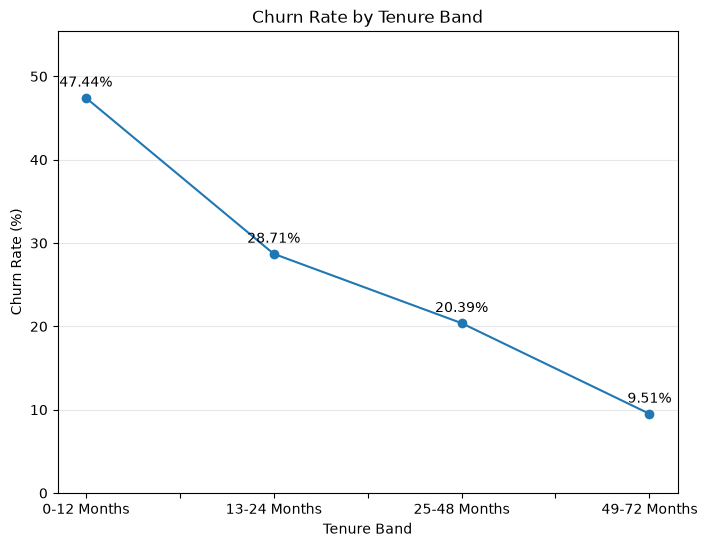

In [28]:
tenure_churn_rate = tenure_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = tenure_churn_rate.plot(kind="line", marker="o")

plt.title("Churn Rate by Tenure Band")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tenure_churn_rate):
    ax.annotate(
        f"{value:.2f}%",
        (i, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.ylim(0, max(tenure_churn_rate) + 8)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 📌 Business Observation — Tenure

**Observation**

Customer churn decreases consistently as tenure increases. Customers in the **0–12 month** tenure band have the highest churn rate at **47.44%**, while customers with **49–72 months** of tenure have the lowest churn rate at **9.51%**.

**Business Impact**

The first year represents the highest customer retention risk. The churn rate for customers in their first 12 months is nearly **five times** that of customers with 49–72 months of tenure.

**Key Insight**

Tenure shows a strong inverse association with churn, indicating that **early-stage customers require greater retention attention**.

**Next Step**

Analyze **Contract Type** to determine whether contract structure is associated with customer churn.

## Contract Type Analysis

This analysis examines whether customer churn differs across contract types.

Contract structure can influence customer commitment and retention, so churn rates are compared within each contract category.

In [29]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


## 📌 Business Observation — Contract Type

**Observation**

Churn varies substantially across contract types. Customers on month-to-month contracts have the highest churn rate at **42.71%**, compared with **11.27%** for one-year contracts and only **2.83%** for two-year contracts.

**Business Impact**

Customers on month-to-month contracts represent a significantly higher retention risk. Their churn rate is approximately **15 times** that of customers on two-year contracts.

**Key Insight**

Contract type shows one of the strongest associations with churn observed so far. Longer-term contracts are associated with substantially lower churn rates.

**Next Step**

Analyze **payment method and billing behavior** to determine whether payment preferences are also associated with customer churn.

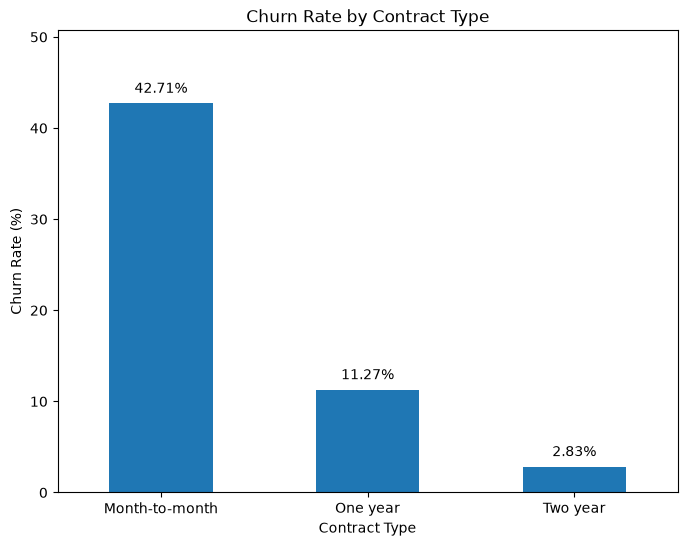

In [30]:
contract_churn_rate = contract_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = contract_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(contract_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(contract_churn_rate) + 8)

plt.show()

In [31]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


## 📌 Business Observation — Payment Method

**Observation**

Churn varies substantially across payment methods. Customers using **Electronic check** have the highest churn rate at **45.29%**, while customers using automatic credit card payments have the lowest churn rate at **15.24%**.

**Business Impact**

Electronic check customers represent a significantly higher retention risk. Their churn rate is approximately **three times** that of customers using automatic credit card payments.

**Key Insight**

Payment method is strongly associated with churn, with electronic check customers showing substantially higher churn than customers using other payment methods.

**Next Step**

Investigate whether **Paperless Billing** and **Monthly Charges** provide additional insight into billing-related churn behavior.

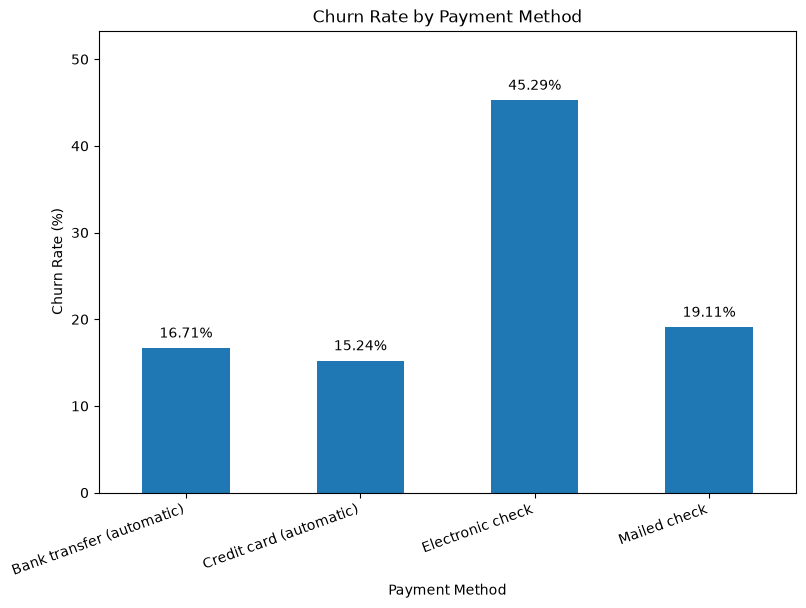

In [32]:
payment_churn_rate = payment_churn["Yes"]

plt.figure(figsize=(9, 6))

ax = payment_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")

for i, value in enumerate(payment_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(payment_churn_rate) + 8)

plt.show()

In [33]:
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


## 📌 Business Observation — Paperless Billing

**Observation**

Customers using paperless billing have a churn rate of **33.57%**, compared with **16.33%** among customers who do not use paperless billing.

**Business Impact**

The churn rate among paperless-billing customers is approximately **twice** that of customers using non-paperless billing, representing a difference of **17.24 percentage points**.

**Key Insight**

Paperless Billing is associated with a meaningful difference in customer churn. However, this relationship should be interpreted alongside other variables such as **Contract, Tenure, and Payment Method**, which may help explain the observed pattern.

**Next Step**

Analyze **Monthly Charges** to determine whether billing amount is associated with customer churn.

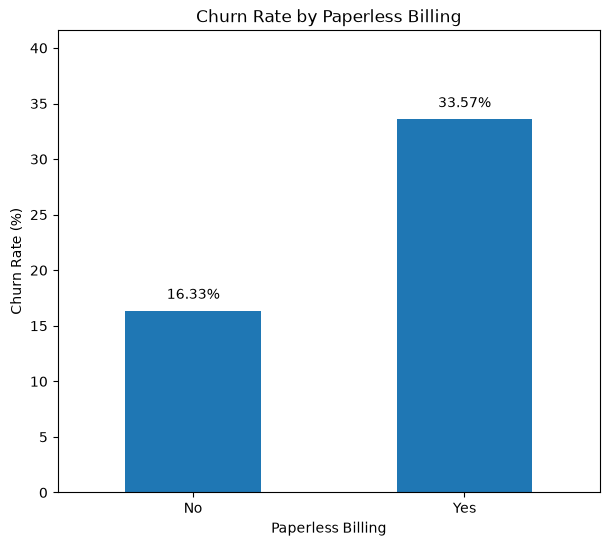

In [34]:
paperless_churn_rate = paperless_churn["Yes"]

plt.figure(figsize=(7, 6))

ax = paperless_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(paperless_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(paperless_churn_rate) + 8)

plt.show()

## Monthly Charges Analysis

Monthly Charges represent the customer's recurring monthly billing amount.

This analysis examines whether monthly charges differ between customers who churn and those who remain with the company.

In [35]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


<Figure size 700x600 with 0 Axes>

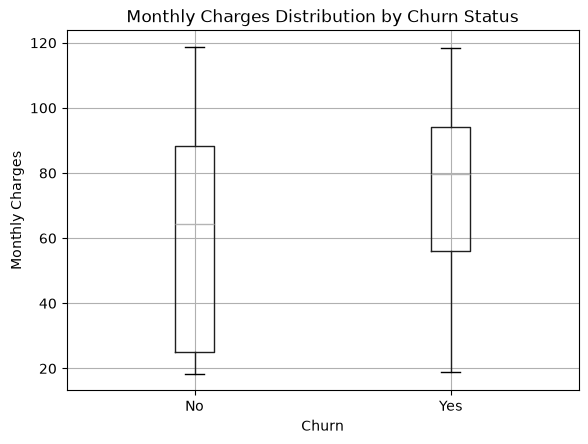

In [36]:
plt.figure(figsize=(7, 6))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## 📌 Business Observation — Monthly Charges

**Observation**

Customers who churn have higher monthly charges than retained customers. The median monthly charge is **79.65** for churned customers compared with **64.43** for retained customers.

**Business Impact**

The median monthly charge for churned customers is approximately **15.23 higher** than for retained customers, indicating that higher monthly charges are associated with increased churn risk.

**Key Insight**

Monthly Charges show a meaningful association with churn, with the churned customer distribution shifted toward higher monthly billing amounts.

**Next Step**

Analyze **Total Charges** to examine whether overall customer spending shows a similar relationship with churn.

In [37]:
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


<Figure size 700x600 with 0 Axes>

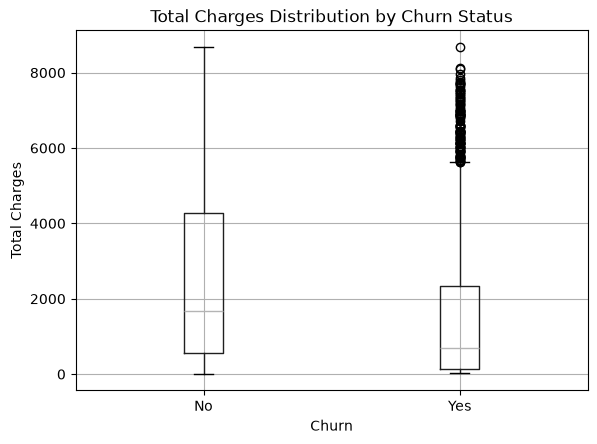

In [38]:
plt.figure(figsize=(7, 6))

df.boxplot(
    column="TotalCharges",
    by="Churn"
)

plt.title("Total Charges Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

## 📌 Business Observation — Total Charges

**Observation**

Customers who churn have substantially lower total charges than retained customers. The median total charge is **703.55** for churned customers compared with **1,679.53** for retained customers.

**Business Impact**

The lower total charges among churned customers are consistent with their shorter customer tenure, as customers who leave earlier have had less time to accumulate charges.

**Key Insight**

Unlike Monthly Charges, which are higher among churned customers, Total Charges are lower among churned customers. This highlights the importance of considering **tenure and billing variables together** rather than interpreting individual variables in isolation.

**Next Step**

Analyze **services and customer engagement variables** to identify additional factors associated with churn.

In [39]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


## 📌 Business Observation — Internet Service

**Observation**

Churn varies substantially by internet service type. Customers using **Fiber optic** service have the highest churn rate at **41.89%**, compared with **18.96%** for DSL customers and **7.40%** among customers without internet service.

**Business Impact**

Fiber optic customers have a substantially higher churn rate than DSL customers, with a difference of **22.93 percentage points**.

**Key Insight**

Internet service type is strongly associated with churn, with Fiber optic customers representing a significantly higher-risk segment.

**Next Step**

Investigate individual **internet service features** such as OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, and Streaming services to determine whether specific service combinations are associated with higher churn.

In [40]:
online_security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

online_security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


## 📌 Business Observation — Online Security

**Observation**

Customers without OnlineSecurity have a churn rate of **41.77%**, compared with **14.61%** among customers who have OnlineSecurity. Customers with no internet service have the lowest churn rate at **7.40%**.

**Business Impact**

Among customers with internet service, those without OnlineSecurity have a substantially higher churn rate, with a difference of **27.16 percentage points** compared with customers who have the service.

**Key Insight**

OnlineSecurity is strongly associated with customer churn. Customers subscribed to OnlineSecurity show substantially lower churn than customers who do not have the service.

**Next Step**

Analyze **OnlineBackup** to determine whether the pattern extends to other additional internet services.

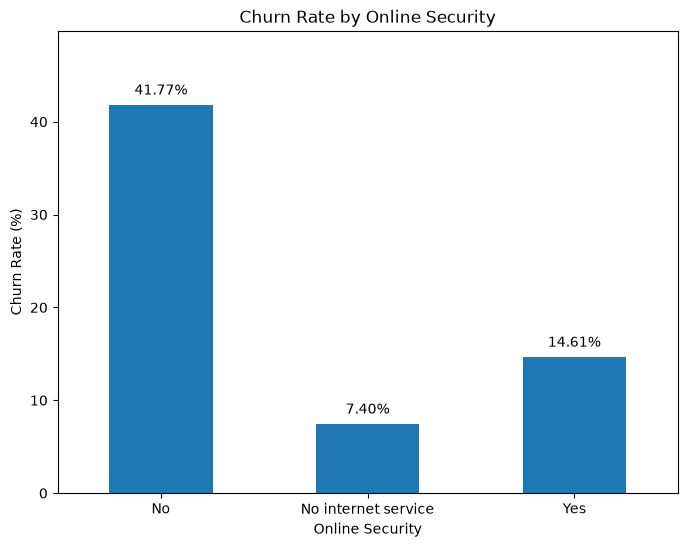

In [41]:
online_security_churn_rate = online_security_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = online_security_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(online_security_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(online_security_churn_rate) + 8)

plt.show()

In [42]:
online_backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

online_backup_churn

Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


## 📌 Business Observation — Online Backup

**Observation**

Customers without OnlineBackup have a churn rate of **39.93%**, compared with **21.53%** among customers who have OnlineBackup. Customers with no internet service have the lowest churn rate at **7.40%**.

**Business Impact**

Among customers with internet service, those without OnlineBackup have an **18.40 percentage-point** higher churn rate than customers who have the service.

**Key Insight**

OnlineBackup is associated with lower customer churn. The relationship is meaningful, although the difference is smaller than the **27.16 percentage-point** gap observed for OnlineSecurity.

**Next Step**

Analyze **DeviceProtection** to determine whether the relationship continues across other additional services.

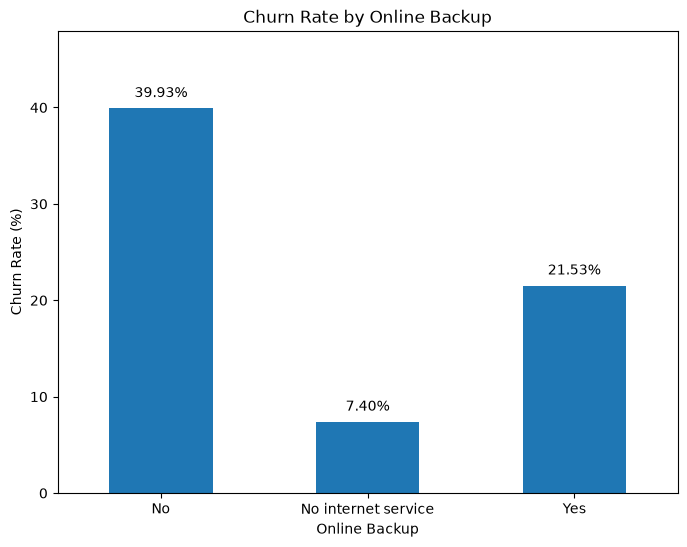

In [43]:
online_backup_churn_rate = online_backup_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = online_backup_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(online_backup_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(online_backup_churn_rate) + 8)

plt.show()

In [44]:
device_protection_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

device_protection_churn

Churn,No,Yes
DeviceProtection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


## 📌 Business Observation — Device Protection

**Observation**

Customers without DeviceProtection have a churn rate of **39.13%**, compared with **22.50%** among customers who have DeviceProtection. Customers with no internet service have the lowest churn rate at **7.40%**.

**Business Impact**

Among customers with internet service, customers without DeviceProtection have a **16.63 percentage-point** higher churn rate than customers who have the service.

**Key Insight**

DeviceProtection is associated with lower customer churn. The relationship is meaningful, although the churn-rate difference is smaller than those observed for OnlineSecurity and OnlineBackup.

**Next Step**

Analyze **TechSupport** to determine whether support-related services show a similar relationship with customer churn.

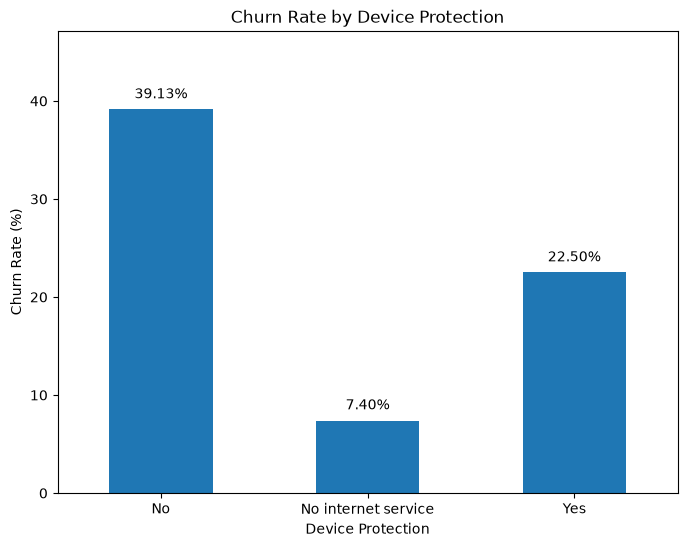

In [46]:
device_protection_churn_rate = device_protection_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = device_protection_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(device_protection_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(device_protection_churn_rate) + 8)

plt.show()

In [47]:
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


## 📌 Business Observation — Tech Support

**Observation**

Customers without TechSupport have a churn rate of **41.64%**, compared with **15.17%** among customers who have TechSupport. Customers with no internet service have the lowest churn rate at **7.40%**.

**Business Impact**

Among customers with internet service, customers without TechSupport have a **26.47 percentage-point** higher churn rate than customers who have the service.

**Key Insight**

TechSupport is strongly associated with lower customer churn. The churn-rate difference is similar in magnitude to the relationship observed for OnlineSecurity.

**Next Step**

Analyze **Streaming services** to determine whether entertainment-related services show a similar relationship with churn.

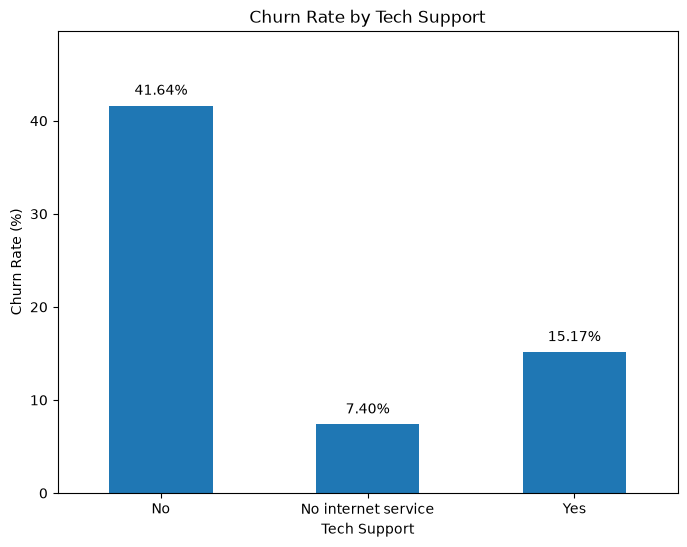

In [48]:
tech_support_churn_rate = tech_support_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = tech_support_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(tech_support_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(tech_support_churn_rate) + 8)

plt.show()

In [49]:
streaming_tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

streaming_tv_churn

Churn,No,Yes
StreamingTV,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


## 📌 Business Observation — Streaming TV

**Observation**

Customers without StreamingTV have a churn rate of **33.52%**, compared with **30.07%** among customers who have the service. Customers with no internet service have the lowest churn rate at **7.40%**.

**Business Impact**

Among customers with internet service, the difference in churn between StreamingTV users and non-users is only **3.45 percentage points**, indicating a relatively weak association compared with other internet services.

**Key Insight**

StreamingTV appears to have a weaker relationship with churn than services such as OnlineSecurity and TechSupport.

**Next Step**

Analyze **StreamingMovies** to determine whether the same pattern exists for movie-streaming services.

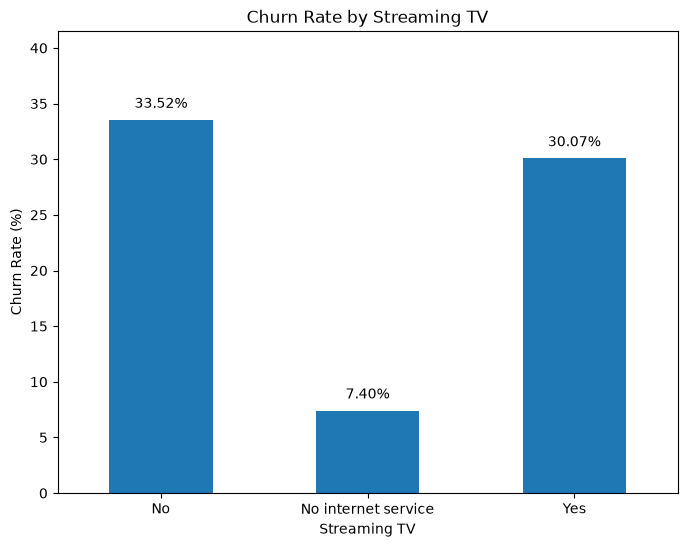

In [50]:
streaming_tv_churn_rate = streaming_tv_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = streaming_tv_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(streaming_tv_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(streaming_tv_churn_rate) + 8)

plt.show()

In [51]:
streaming_movies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

streaming_movies_churn

Churn,No,Yes
StreamingMovies,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


## 📌 Business Observation — Streaming Movies

**Observation**

Customers without StreamingMovies have a churn rate of **33.68%**, compared with **29.94%** among customers who have the service. Customers with no internet service have the lowest churn rate at **7.40%**.

**Business Impact**

Among customers with internet service, the difference in churn between StreamingMovies users and non-users is only **3.74 percentage points**, indicating a relatively weak association compared with services such as OnlineSecurity and TechSupport.

**Key Insight**

StreamingMovies shows a relatively weak relationship with churn, similar to StreamingTV.

**Next Step**

Complete the services analysis and summarize the relative strength of the service-level churn patterns before moving to the final EDA comparisons.

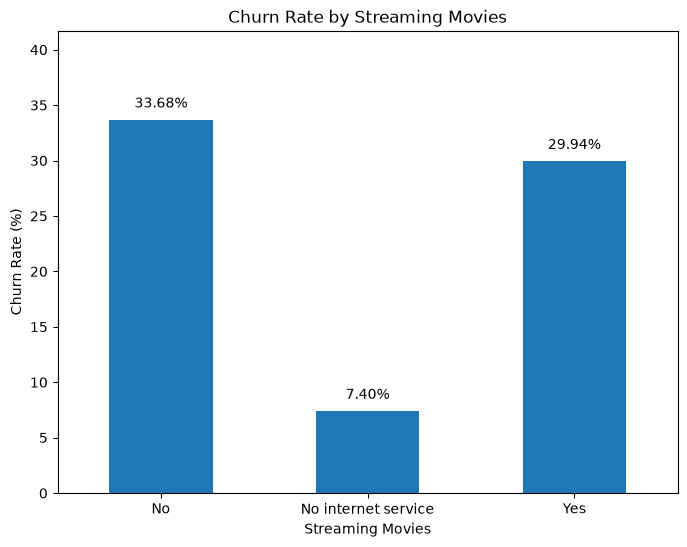

In [52]:
streaming_movies_churn_rate = streaming_movies_churn["Yes"]

plt.figure(figsize=(8, 6))

ax = streaming_movies_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(streaming_movies_churn_rate):
    ax.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(streaming_movies_churn_rate) + 8)

plt.show()

## 📌 Services Analysis — Summary

### Key Observations

Service-level churn varies considerably across different internet-related services.

- **OnlineSecurity** shows the strongest association with churn. Customers without OnlineSecurity have a churn rate of **41.77%**, compared with **14.61%** among customers with the service — a difference of **27.16 percentage points**.

- **TechSupport** shows a similarly strong pattern, with churn rates of **41.64%** for customers without the service versus **15.17%** for customers with TechSupport — a difference of **26.47 percentage points**.

- **OnlineBackup** and **DeviceProtection** also show meaningful differences, with churn gaps of **18.40** and **16.63 percentage points**, respectively.

- **StreamingTV** and **StreamingMovies** show relatively weak differences in churn, with gaps of only **3.45** and **3.74 percentage points**, respectively, among customers with internet service.

### Business Insight

Security and support-related services show substantially stronger associations with churn than entertainment-related services. Customers without **OnlineSecurity** or **TechSupport** represent particularly high-churn segments.

### Analytical Caution

These findings represent **associations, not causal relationships**. Service adoption may be related to other customer characteristics such as **contract type, tenure, InternetService, and payment method**.

The Machine Learning stage will evaluate the combined predictive importance of these variables.

# EDA Summary / Key Churn Drivers

## Overall Churn

The dataset contains **7,043 customers**, of whom **1,869 (26.54%)** have churned.

The exploratory analysis identified several customer characteristics and account behaviors that are strongly associated with churn.

## Key Churn Drivers

### 1. Tenure
Churn decreases consistently as customer tenure increases.

- **0–12 months:** 47.44% churn
- **49–72 months:** 9.51% churn

Newer customers represent the highest retention-risk segment.

### 2. Contract Type
Contract type shows one of the strongest associations with churn.

- **Month-to-month:** 42.71% churn
- **One year:** 11.27%
- **Two year:** 2.83%

Longer-term contracts are associated with substantially lower churn.

### 3. Payment Method
Electronic check customers show substantially higher churn.

- **Electronic check:** 45.29%
- **Credit card (automatic):** 15.24%

This represents a **30.05 percentage-point difference**.

### 4. Internet Service
Fiber optic customers show considerably higher churn than DSL customers.

- **Fiber optic:** 41.89%
- **DSL:** 18.96%
- **No internet service:** 7.40%

### 5. Security & Support Services
Security and support-related services show strong associations with lower churn.

- **OnlineSecurity:** 41.77% without vs. 14.61% with
- **TechSupport:** 41.64% without vs. 15.17% with

These represent the strongest service-level differences observed.

### 6. Monthly Charges
Churned customers have higher monthly charges.

- **Churned median:** 79.65
- **Retained median:** 64.43

Higher monthly charges are associated with higher churn.

### 7. Household Characteristics
Household characteristics also show meaningful differences.

- **Senior citizens:** 41.68% churn
- **Non-senior customers:** 23.61%
- **Customers without dependents:** 31.28%
- **Customers with dependents:** 15.45%

### 8. Gender
Gender shows very little difference in churn.

- **Female:** 26.92%
- **Male:** 26.16%

This suggests that gender is a relatively weak churn indicator compared with tenure, contract type, payment method, and service-related variables.

---

## Key Business Insights

The EDA suggests that customer churn is concentrated among customers with a combination of:

- **Short tenure**
- **Month-to-month contracts**
- **Higher monthly charges**
- **Electronic check payment**
- **Fiber optic internet service**
- **No OnlineSecurity or TechSupport**

In contrast, customers with longer tenure and longer-term contracts show substantially lower churn.

## Analytical Caution

These findings represent **associations, not causal relationships**. Several variables may be interrelated.

For example, tenure, contract type, monthly charges, payment method, and internet services may jointly describe the same underlying customer behavior.

Therefore, individual churn-rate comparisons should not be interpreted as independent effects.

## Transition to Machine Learning

The next stage will use **Machine Learning** to evaluate these variables simultaneously and identify which features provide the strongest predictive signal for customer churn.